In [5]:
import pandas as pd
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import os


In [7]:
# Download VADER lexicon (required for sentiment scoring)
nltk.download('vader_lexicon')

[nltk_data] Error loading vader_lexicon: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


False

In [9]:
# 1. LOAD DATA

def perform_task_3(news_df, stock_df):
    # A. SENTIMENT SCORING (using VADER)
    sia = SentimentIntensityAnalyzer()
    news_df['sentiment_score'] = news_df['headline'].apply(lambda x: sia.polarity_scores(x)['compound'])
    
    # B. DATE ALIGNMENT
    news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce', utc=True).dt.date
    stock_df['Date'] = pd.to_datetime(stock_df['Date'], errors='coerce', utc=True).dt.date
    news_df = news_df.dropna(subset=['date'])
    stock_df = stock_df.dropna(subset=['Date'])
    # C. AGGREGATE SENTIMENT
    # Average sentiment per day, per stock
    daily_sentiment = news_df.groupby(['date', 'stock'])['sentiment_score'].mean().reset_index()
    daily_sentiment.columns = ['Date', 'Ticker', 'Average_Sentiment']
    
    # D. MERGE DATASETS
    merged_df = pd.merge(daily_sentiment, stock_df, on=['Date', 'Ticker'], how='inner')
    
    # E. CALCULATE CORRELATION
    correlation = merged_df['Average_Sentiment'].corr(merged_df['Daily_Return'])
    print(f"Pearson Correlation Coefficient: {correlation:.4f}")
    
    return merged_df, correlation



In [10]:
# 2. VISUALIZATION
def plot_correlation(merged_df, correlation):
    plt.figure(figsize=(10, 6))
    sns.regplot(x='Average_Sentiment', y='Daily_Return', data=merged_df, scatter_kws={'alpha':0.5})
    plt.title(f'News Sentiment vs. Stock Returns (Corr: {correlation:.4f})')
    plt.xlabel('Average Daily Sentiment Score')
    plt.ylabel('Daily Stock Return (%)')
    plt.grid(True)
    plt.savefig('sentiment_return_correlation.png')
    print("✅ Plot saved as sentiment_return_correlation.png")
    plt.show()


Pearson Correlation Coefficient: 0.1709
✅ Plot saved as sentiment_return_correlation.png


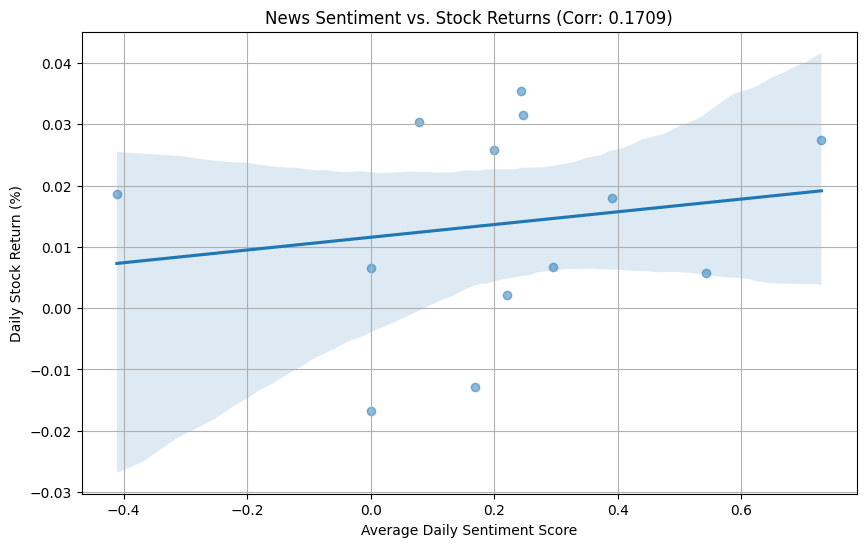

In [11]:
# --- THE EXECUTION CALLS ---
STOCK_FILE = '../data/stock_results.csv' 
NEWS_FILE = '../data/raw/raw_analyst_ratings.csv' 

if os.path.exists(NEWS_FILE) and os.path.exists(STOCK_FILE):
    news_data = pd.read_csv(NEWS_FILE)
    stock_data = pd.read_csv(STOCK_FILE)

    merged_data, corr_val = perform_task_3(news_data, stock_data)
    plot_correlation(merged_data, corr_val)